# Spatial distribution of TCR clonotypes

**How are TCR clonotypes spatially distributed in the tissue?**

We first visualize where TCR clonotypes are located in the tissue.
We then calculate the mean spatial distance between cells belonging to the same clonotype.

**What is the average spatial distance between cells belonging to the same TCR clonotype?**

In [1]:
# Resolve local imports and dataset paths from the repository root or notebooks/.
import os
import sys
from pathlib import Path

working_directory = Path.cwd().resolve()
repository_root = next(
    (directory for directory in (working_directory, *working_directory.parents)
     if (directory / "helper" / "slide_tags_reader.py").is_file()
     and (directory / "src" / "scirpy").is_dir()),
    None,
)
if repository_root is None:
    raise FileNotFoundError("Start this notebook from the Scirpy repository or its notebooks directory.")
os.chdir(repository_root)
sys.path.insert(0, str(repository_root))
sys.path.insert(0, str(repository_root / "src"))

import matplotlib.pyplot as plt
import scirpy as ir
from helper.slide_tags_reader import read_slidetags

/Users/markusvinzenz/Projects/scirpy/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Slide-tags data

The SCP2176 dataset contains gene expression, TCR information, cell annotations,
and spatial coordinates. The existing reader loads these into SpatialData.
The local `SCP2176/` dataset directory must be present in the repository root;
the notebook uses an environment with the repository's analysis dependencies installed.

In [2]:
sdata = read_slidetags("SCP2176")
sdata

SpatialData object
├── Points
│     └── 'spatial': DataFrame with shape: (<Delayed>, 4) (2D points)
└── Tables
      └── 'adata': AnnData (5704, 36601)
with coordinate systems:
    ▸ 'global', with elements:
        spatial (Points)

## TCR analysis with Scirpy

TCR chains are indexed, receptor quality control is performed, and TCR sequence
distances are calculated. Similar TCRs are grouped into clonotype clusters using
the existing Scirpy pipeline. Here, “clonotype” refers to these clusters.

In [3]:
ir.pp.index_chains(
    sdata,
    filter=["require_junction_aa"],
)

ir.tl.chain_qc(
    sdata
)

ir.pp.ir_dist(
    sdata,
    sequence="aa",
    metric="tcrdist",
)

ir.tl.define_clonotype_clusters(
    sdata,
    sequence="aa",
    metric="tcrdist",
    receptor_arms="any",
    dual_ir="primary_only",
)

/Users/markusvinzenz/Projects/scirpy/src/scirpy/io/_convert_anndata.py:52: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  adata = AnnData(
/Users/markusvinzenz/Projects/scirpy/src/scirpy/ir_dist/metrics.py:1514: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  data_rows[row_index][0] = data_row_matrix[thread_id, 0:row_end_index].copy()


## Spatial visualization of clonotypes

Before calculating a distance metric, the spatial distribution of the
clonotypes is visualized directly in the tissue.

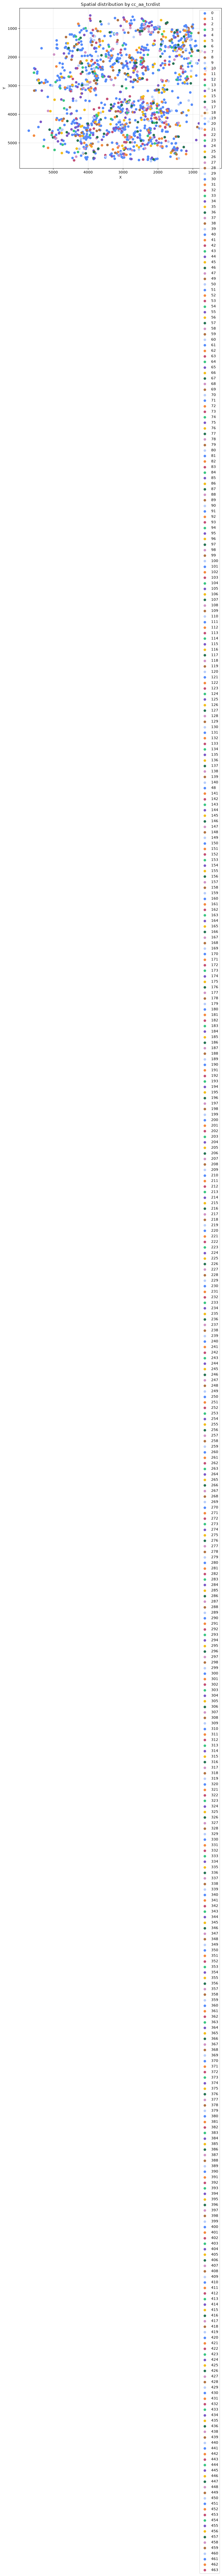

In [4]:
plt.figure(figsize=(10, 8))
ir.pl.plot_spatial(
    sdata,
    color="cc_aa_tcrdist",
)
plt.show()
plt.close()

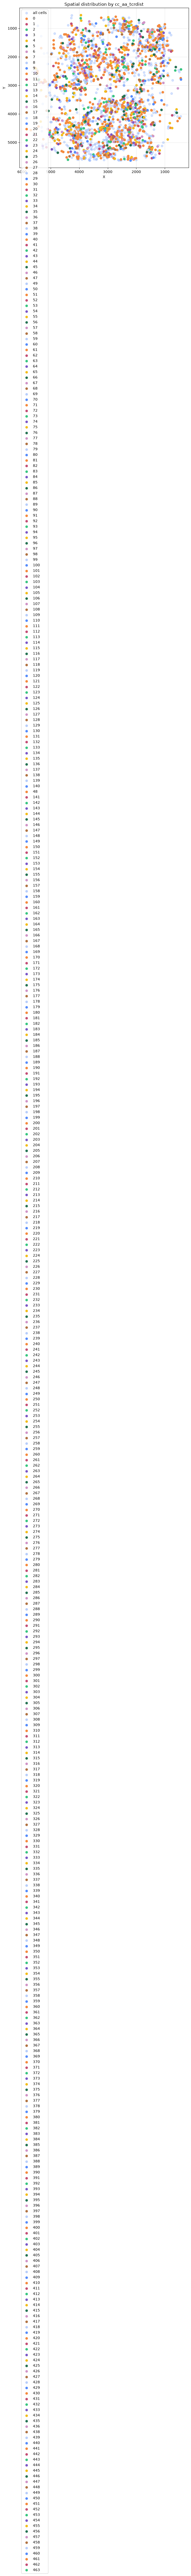

In [5]:
plt.figure(figsize=(10, 8))
ir.pl.plot_spatial_all(
    sdata,
    color="cc_aa_tcrdist",
)
plt.show()
plt.close()

`plot_spatial` shows cells with spatial coordinates and a non-missing value
for the selected clonotype key. `plot_spatial_all` additionally shows all
spatially recorded cells as a background, including cells without a clonotype
assignment. Each plot is drawn in a separate figure.

The current dataset also contains the cell annotation `tumour_1`. The following
optional view selects cells with this annotation; it does not define a geometric
tumour boundary.

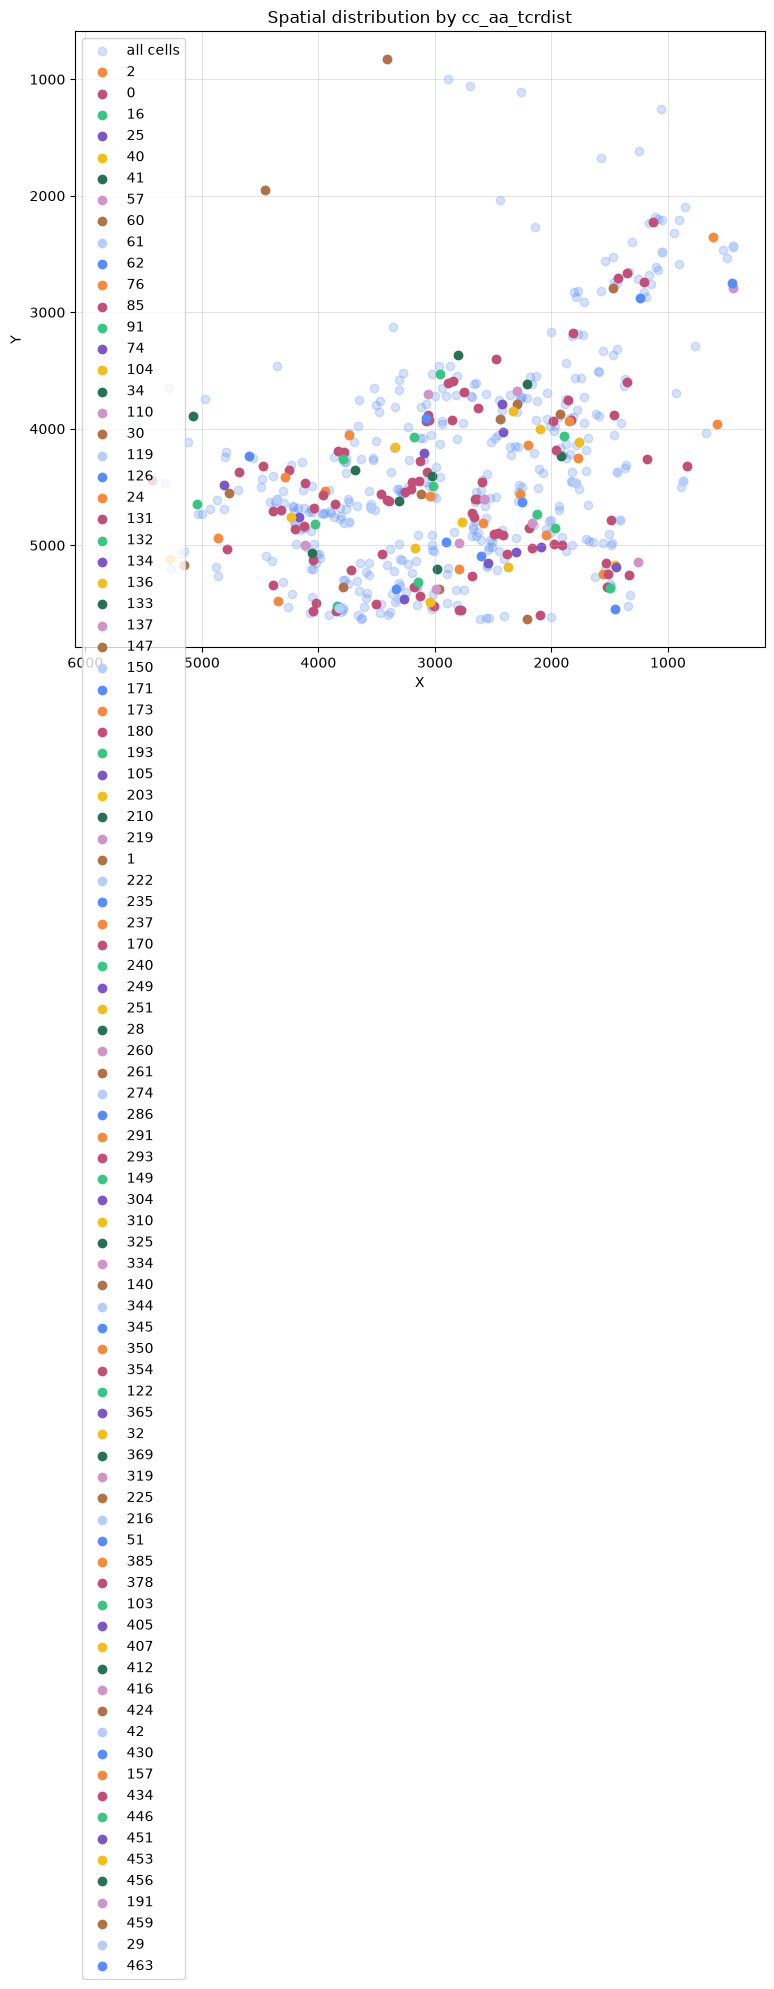

In [6]:
adata = sdata.tables["adata"]
if "cell_type" in adata.obs and adata.obs["cell_type"].eq("tumour_1").any():
    plt.figure(figsize=(10, 8))
    ir.pl.plot_spatial_all(
        sdata,
        color="cc_aa_tcrdist",
        filter_by="cell_type",
        filter_value="tumour_1",
    )
    plt.show()
    plt.close()
else:
    print("No tumour_1 annotation is available; this optional plot is skipped.")

## Spatial distance within clonotypes

The spatial plots provide a visual impression of clonotype distribution.
To describe this distribution quantitatively, the average pairwise distance
between cells of the same clonotype is calculated.

In [7]:
ir.tl.spatial_clonotype_distance(sdata)

adata = sdata.tables["adata"]
result = adata.uns["spatial_clonotype_distance"]

result.head()

,n_cells,n_cells_spatial,mean_pairwise_distance,median_pairwise_distance,mean_nearest_neighbor_distance
cc_aa_tcrdist,,,,,
0,636,635,2294.485693,2250.466547,80.796809
1,6,6,2134.956823,2205.316013,950.632382
2,10,10,2794.502352,2927.903878,923.088267
3,1,1,NaN,NaN,NaN
4,2,2,2078.918425,2078.918425,2078.918425


The result contains one row per observed clonotype:

| Column | Meaning |
| --- | --- |
| `n_cells` | All cells assigned to the clonotype. |
| `n_cells_spatial` | Assigned cells with valid x/y coordinates. |
| `mean_pairwise_distance` | Mean Euclidean distance between all unordered pairs of mapped cells of the same clonotype; each pair is counted once. **This is the primary metric for this example.** |
| `median_pairwise_distance` | Median of these pairwise distances. |
| `mean_nearest_neighbor_distance` | Mean distance to the nearest other mapped cell of the same clonotype; an additional local density metric. |

Smaller mean pairwise distances indicate that cells of the clonotype are
spatially more compact; larger values indicate a more dispersed distribution.
Cells without a clonotype assignment are ignored. Missing or non-finite
coordinates are excluded from distances but still count towards `n_cells`.
With fewer than two valid spatial cells, all distance metrics are `NaN`.

The analysis is purely descriptive: no p-values, significance tests, or
conclusions about migration are produced. Distances use the supplied coordinate
units; a physical unit such as µm is not documented by the reader. Pairwise
calculations require quadratic time and memory for large clonotypes.

In [8]:
plot_data = (
    result[
        (result["n_cells_spatial"] >= 5)
        & result["mean_pairwise_distance"].notna()
    ]
    .sort_values("mean_pairwise_distance")
)

plot_data

,n_cells,n_cells_spatial,mean_pairwise_distance,median_pairwise_distance,mean_nearest_neighbor_distance
cc_aa_tcrdist,,,,,
12,5,5,1260.669102,1245.804170,748.504799
8,5,5,1652.853777,1361.793407,812.233651
136,8,8,1771.488158,1695.029387,650.789942
1,6,6,2134.956823,2205.316013,950.632382
42,7,7,2273.842201,2200.996029,974.902301
216,5,5,2280.473257,2233.918302,1221.387465
0,636,635,2294.485693,2250.466547,80.796809
149,5,5,2294.514882,2108.614759,1532.341925
24,37,37,2315.751206,2221.907486,397.674258


Clonotypes with fewer than five spatially mapped cells are excluded only
from this visualization, not from the calculation itself.

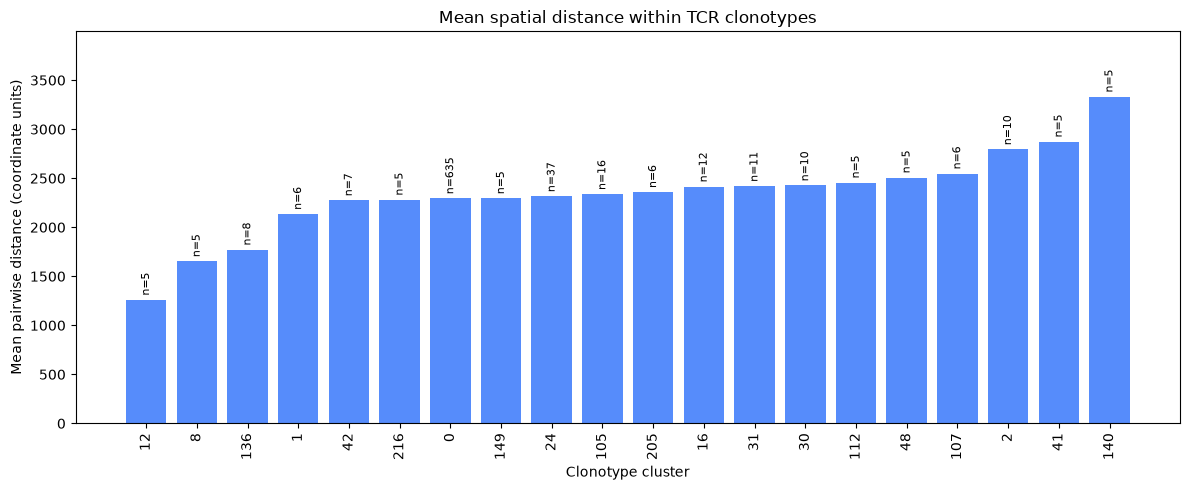

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    plot_data.index.astype(str),
    plot_data["mean_pairwise_distance"],
)
ax.bar_label(
    bars,
    labels=[f"n={int(n)}" for n in plot_data["n_cells_spatial"]],
    padding=3,
    rotation=90,
    fontsize=8,
)

ax.set_xlabel("Clonotype cluster")
# The reader does not specify a physical unit for the supplied X/Y coordinates.
ax.set_ylabel("Mean pairwise distance (coordinate units)")
ax.set_title("Mean spatial distance within TCR clonotypes")
ax.tick_params(axis="x", labelrotation=90)
ax.margins(y=0.2)
fig.tight_layout()

plt.show()
plt.close(fig)

## Interpretation

- Smaller mean pairwise distances indicate a more compact spatial distribution.
- Larger mean pairwise distances indicate a broader spatial distribution.
- The number of spatially mapped cells differs between clonotypes and is displayed as `n` above each bar.
- No statistical significance is inferred.

These summaries describe the observed tissue coordinates. They do not establish
whether cells are closer than expected by chance and do not support conclusions
about cell migration.